<a href="https://colab.research.google.com/github/L-Poca/Data_Pipeline/blob/rafael_cleaning/src/notebooks/transfer_learning_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Transfer Learning - COVID-19 Classification (Colab Pro)

**Objectif :** Classifier les radiographies pulmonaires avec Transfer Learning

**Modèles testés :**
- VGG16 (ImageNet)
- ResNet50 (ImageNet)
- EfficientNetB0 (ImageNet)
- InceptionV3 (ImageNet)

**Dataset :** COVID-19 Radiography (4 classes)
- COVID
- Normal
- Lung_Opacity
- Viral Pneumonia

**Stratégie :**
1. Feature extraction (freeze base)
2. Fine-tuning (unfreeze top layers)

## Initialisation

###  Configuration Standalone

**⚠️ REMPLACER CETTE CELLULE** par le contenu complet de `CELL_CONFIG_STANDALONE.py`

In [ ]:
"""
╔════════════════════════════════════════════════════════════════════════════╗
║  🎯 CELLULE DE CONFIGURATION STANDALONE - COPIER-COLLER DANS VOS NOTEBOOKS ║
╚════════════════════════════════════════════════════════════════════════════╝

INSTRUCTIONS:
-------------
1. Copiez TOUT le contenu de cette cellule
2. Collez-le comme PREMIÈRE CELLULE de votre notebook
3. Exécutez la cellule
4. Les variables sont prêtes à l'emploi !

Cette cellule est 100% autonome et fonctionne partout :
✅ Google Colab (clone + installe automatiquement)
✅ WSL / Linux Local
✅ Tout environnement Jupyter

APRÈS EXÉCUTION, VOUS POUVEZ UTILISER:
- config: Objet de configuration (config.batch_size, config.data_dir, etc.)
- ENV: Environnement détecté ('colab', 'wsl', 'local')
- Tous les imports des transformers

"""

# =============================================================================
# IMPORTS STANDARDS
# =============================================================================

import os
import sys
import subprocess
from pathlib import Path


# =============================================================================
# DÉTECTION AUTOMATIQUE DE L'ENVIRONNEMENT
# =============================================================================

def detect_environment():
    """Détecte l'environnement (colab, wsl, local)"""
    try:
        import google.colab
        return "colab"
    except ImportError:
        is_wsl = os.path.exists('/proc/version') and 'microsoft' in open('/proc/version').read().lower()
        return "wsl" if is_wsl else "local"

ENV = detect_environment()
print(f"🌍 Environnement: {ENV.upper()}")


# =============================================================================
# BOOTSTRAP COLAB (Clone + Install si nécessaire)
# =============================================================================

if ENV == "colab":
    print("\n🚀 Bootstrap Colab...")

    os.chdir('/content')
    if not os.path.exists('/content/Data_Pipeline'):
        print("📥 Clonage du repository...")
        subprocess.run(['git', 'clone', 'https://github.com/L-Poca/Data_Pipeline.git'], check=True)

    os.chdir('/content/Data_Pipeline')

    # Checkout de la branche rafael_cleaning
    result = subprocess.run(
        ['git', 'checkout', '-b', 'rafael_cleaning', 'origin/rafael_cleaning'],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        # Si la branche locale existe déjà, juste switcher
        subprocess.run(['git', 'checkout', 'rafael_cleaning'], capture_output=True)

    print("📦 Installation des dépendances...")
    subprocess.run(['pip', 'install', '-r', 'requirements.txt', '--quiet'], check=True)

    print("📦 Installation du package...")
    result = subprocess.run(['pip', 'install', '-e', '.', '--quiet'], capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️ Erreur installation: {result.stderr}")
    else:
        print("✅ Package installé")

    print("💾 Montage Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')

    # Extraction dataset
    for archive in ['/content/drive/MyDrive/DS_COVID/archive_covid.zip']:
        if os.path.exists(archive):
            print("📦 Extraction dataset...")
            os.makedirs('./data/raw/', exist_ok=True)
            subprocess.run(['unzip', '-o', '-q', archive, '-d', './data/raw/COVID-19_Radiography_Dataset/'])
            break

    print("✅ Bootstrap terminé")


# =============================================================================
# CONFIGURATION DES CHEMINS
# =============================================================================

# Déterminer project_root selon l'environnement
if ENV == "colab":
    project_root = Path('/content/Data_Pipeline')
elif ENV == "wsl":
    #project_root = Path('/home/cepa/DST/projet_DS/Data_Pipeline/Data_Pipeline')
    project_root = Path.cwd().parent.parent  # Ajuster selon l'emplacement réel
    print(f"✅ Chemin projet WSL: {project_root}")
else:  # local
    # Depuis un notebook dans src/notebooks/
    project_root = Path.cwd().parent.parent

# Ajouter src/ au sys.path pour les imports
# src_path = str(project_root)
# if src_path not in sys.path:
#     sys.path.insert(0, src_path)
#     print(f"✅ Chemin src/ ajouté: {src_path}")

# Charger la configuration depuis JSON
from src.utils.config import build_config

config = build_config(project_root, ENV)

# Exports pour compatibilité avec anciens notebooks
data_dir = config.data_dir
categories = config.classes
img_size = config.img_size


# =============================================================================
# IMPORTS DES TRANSFORMERS
# =============================================================================

try:
    from src.features.Pipelines.Transformateurs.image_loaders import ImageLoader
    from src.features.Pipelines.Transformateurs.image_preprocessing import (
        ImageResizer, ImageNormalizer, ImageFlattener
    )
    from src.features.Pipelines.Transformateurs.image_augmentation import (
        ImageAugmenter, ImageRandomCropper
    )
    from src.features.Pipelines.Transformateurs.image_features import (
        ImageHistogram, ImagePCA, ImageStandardScaler
    )
    print("✅ Transformers importés")
except ImportError as e:
    print(f"⚠️ Erreur import transformers: {e}")


# =============================================================================
# IMPORTS ML/DL
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# =============================================================================
# CONFIGURATION MATPLOTLIB
# =============================================================================

plt.rcParams['figure.figsize'] = (15, 10)
sns.set_style('whitegrid')

# =============================================================================
# AFFICHAGE DU RÉSUMÉ
# =============================================================================

print("\n" + "=" * 70)
print("✅ CONFIGURATION PRÊTE - Data Pipeline")
print("=" * 70)
print(f"📂 Projet: {project_root}")
print(f"📊 Dataset: {data_dir}")
print(f"🏷️ Classes: {', '.join(categories)}")
print(f"🎛️ Images: {img_size}")
print(f"🔧 Batch: {config.batch_size} | Époques: {config.epochs}")
print(f"📐 Dataset accessible: {'✅' if data_dir.exists() else '❌'}")
if not data_dir.exists():
    print(f"   ⚠️ Créez le dossier ou placez les données dans: {data_dir}")
print("=" * 70)
print("\n💡 Variables disponibles:")
print("   • config: Configuration complète (Config object)")
print("   • project_root: Racine du projet (Path)")
print("   • data_dir: Dossier des données (Path)")
print("   • categories: Liste des 4 classes")
print("   • img_size: Taille des images (tuple)")
print("   • ENV: Environnement actuel")
print("\n🎯 Transformers disponibles:")
print("   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener")
print("   • ImageAugmenter, ImageRandomCropper")
print("   • ImageHistogram, ImagePCA, ImageStandardScaler")
print("=" * 70)


🌍 Environnement: WSL
✅ Chemin projet WSL: /home/lena/Data_Pipeline
✅ Chemin src/ ajouté: /home/lena/Data_Pipeline
✅ Transformers importés


2025-11-06 12:09:14.988532: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



✅ CONFIGURATION PRÊTE - Data Pipeline
📂 Projet: /home/lena/Data_Pipeline
📊 Dataset: /home/lena/Data_Pipeline/data/raw/COVID-19_Radiography_Dataset/COVID-19_Radiography_Dataset
🏷️ Classes: COVID, Normal, Lung_Opacity, Viral Pneumonia
🎛️ Images: (256, 256)
🔧 Batch: 32 | Époques: 100
📐 Dataset accessible: ✅

💡 Variables disponibles:
   • config: Configuration complète (Config object)
   • project_root: Racine du projet (Path)
   • data_dir: Dossier des données (Path)
   • categories: Liste des 4 classes
   • img_size: Taille des images (tuple)
   • ENV: Environnement actuel

🎯 Transformers disponibles:
   • ImageLoader, ImageResizer, ImageNormalizer, ImageFlattener
   • ImageAugmenter, ImageRandomCropper
   • ImageHistogram, ImagePCA, ImageStandardScaler


### Vérification GPU

In [ ]:
print("=" * 70)
print("VÉRIFICATION GPU")
print("=" * 70)

# Vérifier GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ GPU disponible: {len(gpus)} GPU(s)")
    for gpu in gpus:
        print(f"   • {gpu.name}")

    # Configurer la mémoire GPU
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("   • Memory growth activé")
else:
    print("\n⚠️ Pas de GPU disponible - utilisation CPU")
    print("   Pour activer GPU sur Colab: Runtime > Change runtime type > GPU")

print(f"\nTensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

VÉRIFICATION GPU

✅ GPU disponible: 1 GPU(s)
   • /physical_device:GPU:0
   • Memory growth activé

TensorFlow version: 2.20.0
Keras version: 3.12.0


## Data Process

### Chargement des Données

In [ ]:
print("=" * 70)
print("CHARGEMENT DES DONNÉES")
print("=" * 70)

# Nombre d'images par classe (Colab Pro peut gérer plus)
N_IMAGES_PER_CLASS = 1345  # Ajuster selon GPU disponible, if None = toutes les images

image_paths = []
labels = []
labels_int = []

for idx, cat in enumerate(categories):
    cat_path = data_dir / cat / 'images'
    if cat_path.exists():
        imgs = sorted(list(cat_path.glob('*.png')))
        if N_IMAGES_PER_CLASS:
            imgs = imgs[:N_IMAGES_PER_CLASS]
        
        image_paths.extend(imgs)
        labels.extend([cat] * len(imgs))
        labels_int.extend([idx] * len(imgs))
        print(f"  {cat:20s}: {len(imgs):4d} images")

labels_int = np.array(labels_int)

print(f"\n  Total: {len(image_paths)} images")
print(f"  Classes: {len(categories)}")
print(f"  Distribution: {np.bincount(labels_int)}")

CHARGEMENT DES DONNÉES
  COVID               : 1345 images
  Normal              : 1345 images
  Lung_Opacity        : 1345 images
  Viral Pneumonia     : 1345 images

  Total: 5380 images
  Classes: 4
  Distribution: [1345 1345 1345 1345]


### Preprocessing Pipeline

In [4]:
print("=" * 70)
print("PREPROCESSING PIPELINE - CORRIGÉ")
print("=" * 70)

# ⭐ CORRECTION 2: Pipeline SANS normalisation minmax
# Les modèles ImageNet ont leur propre preprocessing
prep_pipeline = Pipeline([
    ('load', ImageLoader(color_mode='RGB', verbose=False)),  # RGB pour ImageNet
    ('resize', ImageResizer(img_size=(224, 224), verbose=False))  # 224x224 pour ImageNet
    # ⚠️ PAS de normalisation ici - sera fait par preprocess_input
])

print("\nChargement des images...")
images = prep_pipeline.fit_transform(image_paths)

# Convertir en float32 SANS normalisation minmax
images = images.astype('float32')

print(f"\n📊 Images préparées:")
print(f"  Shape: {images.shape}")
print(f"  Range AVANT preprocessing: [{images.min():.1f}, {images.max():.1f}]")
print(f"  Dtype: {images.dtype}")
print("\n⚠️ La normalisation ImageNet sera appliquée par le DataGenerator")

PREPROCESSING PIPELINE - CORRIGÉ

Chargement des images...

📊 Images préparées:
  Shape: (5380, 224, 224, 3)
  Range AVANT preprocessing: [0.0, 255.0]
  Dtype: float32

⚠️ La normalisation ImageNet sera appliquée par le DataGenerator


### Train/Validation/Test Split

In [5]:
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 70)

# Split 70/15/15
X_train_val, X_test, y_train_val, y_test = train_test_split(
    images, labels_int,
    test_size=0.15,
    random_state=config.random_seed,
    stratify=labels_int
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 du total
    random_state=config.random_seed,
    stratify=y_train_val
)

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(categories))
y_val_cat = keras.utils.to_categorical(y_val, num_classes=len(categories))
y_test_cat = keras.utils.to_categorical(y_test, num_classes=len(categories))

print(f"\nTrain set: {X_train.shape[0]} images")
print(f"  Distribution: {np.bincount(y_train)}")
print(f"\nValidation set: {X_val.shape[0]} images")
print(f"  Distribution: {np.bincount(y_val)}")
print(f"\nTest set: {X_test.shape[0]} images")
print(f"  Distribution: {np.bincount(y_test)}")

TRAIN/VALIDATION/TEST SPLIT

Train set: 3768 images
  Distribution: [942 942 942 942]

Validation set: 805 images
  Distribution: [201 202 201 201]

Test set: 807 images
  Distribution: [202 201 202 202]


### Vérification des Données

VÉRIFICATION DES DONNÉES


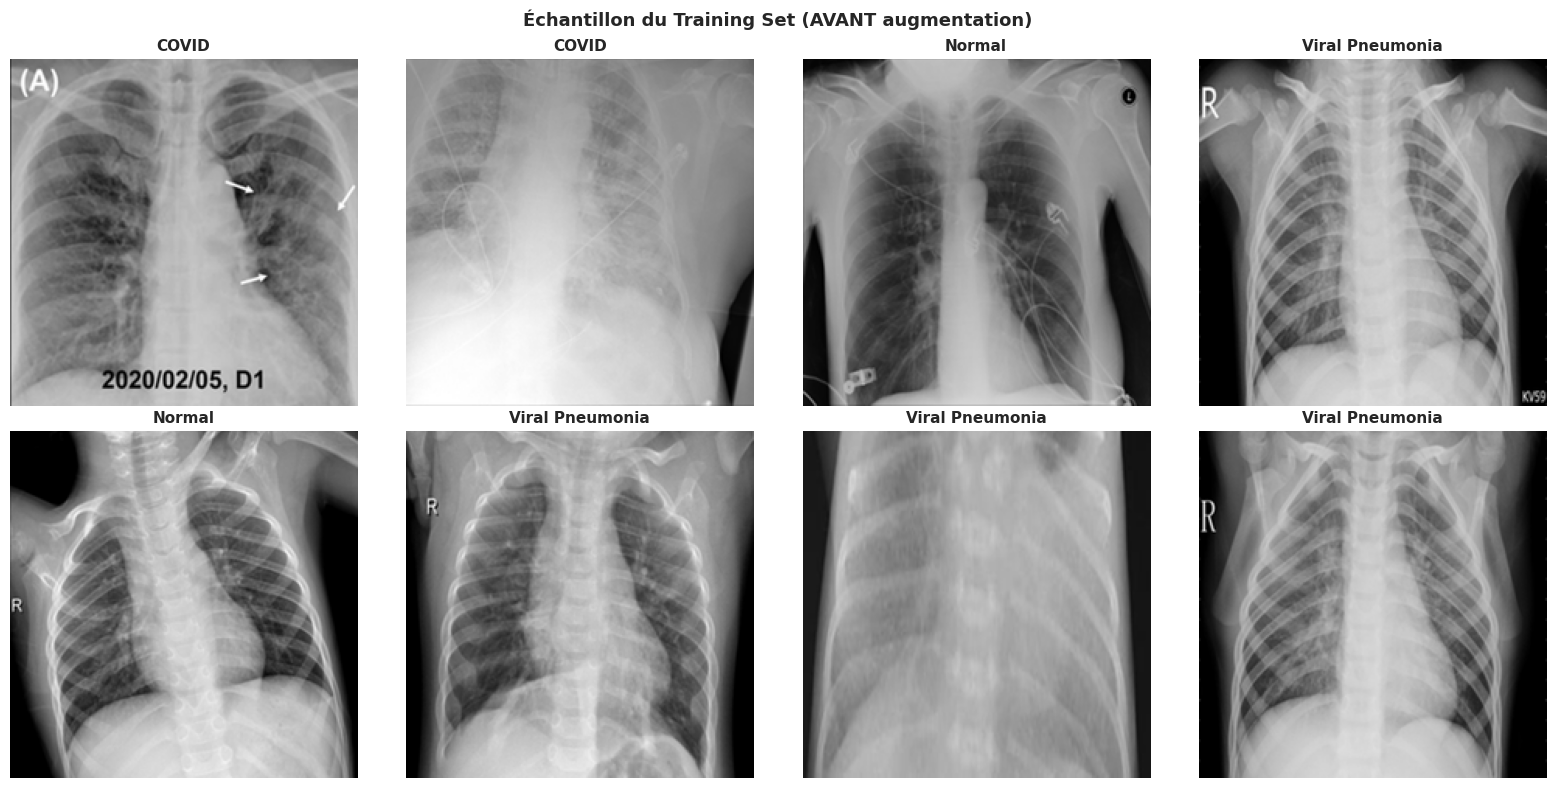


📊 Distribution des classes:
  COVID               : Train= 942 | Val=201 | Test=202
  Normal              : Train= 942 | Val=202 | Test=201
  Lung_Opacity        : Train= 942 | Val=201 | Test=202
  Viral Pneumonia     : Train= 942 | Val=201 | Test=202

📐 Range des images:
  Min: 0.000
  Max: 255.000
  Mean: 130.715
  Std: 63.215

💡 Les images seront normalisées par preprocess_input lors de l'augmentation


In [6]:
import matplotlib.pyplot as plt

print("=" * 70)
print("VÉRIFICATION DES DONNÉES")
print("=" * 70)

# Visualiser quelques images avec leurs labels
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    idx = np.random.randint(0, len(X_train))
    img = X_train[idx]
    label = y_train[idx]
    
    # Dénormaliser pour affichage si nécessaire
    img_display = img.copy()
    if img_display.max() <= 1.0:
        img_display = (img_display * 255).astype(np.uint8)
    
    axes[i].imshow(img_display.astype('uint8'))
    axes[i].set_title(f'{categories[label]}', fontsize=11, weight='bold')
    axes[i].axis('off')

plt.suptitle('Échantillon du Training Set (AVANT augmentation)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Vérifier la distribution
print(f"\n📊 Distribution des classes:")
for idx, cat in enumerate(categories):
    count_train = np.sum(y_train == idx)
    count_val = np.sum(y_val == idx)
    count_test = np.sum(y_test == idx)
    print(f"  {cat:20s}: Train={count_train:4d} | Val={count_val:3d} | Test={count_test:3d}")

# Vérifier le range des données
print(f"\n📐 Range des images:")
print(f"  Min: {X_train.min():.3f}")
print(f"  Max: {X_train.max():.3f}")
print(f"  Mean: {X_train.mean():.3f}")
print(f"  Std: {X_train.std():.3f}")
print(f"\n💡 Les images seront normalisées par preprocess_input lors de l'augmentation")

### Calcul des Class Weights

In [7]:
from sklearn.utils import class_weight

print("=" * 70)
print("CALCUL DES CLASS WEIGHTS")
print("=" * 70)

# Calculer les poids pour équilibrer les classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Créer le dictionnaire de poids
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n📊 Distribution du training set:")
for idx, cat in enumerate(categories):
    count = np.sum(y_train == idx)
    weight = class_weight_dict[idx]
    print(f"  {cat:20s}: {count:4d} images → poids: {weight:.4f}")

print("\n💡 Explication:")
print("  Les classes minoritaires auront un poids plus élevé dans la loss function")
print("  Le modèle sera pénalisé davantage pour les erreurs sur ces classes")
print("\n✅ Class weights calculés et prêts à l'emploi")

CALCUL DES CLASS WEIGHTS

📊 Distribution du training set:
  COVID               :  942 images → poids: 1.0000
  Normal              :  942 images → poids: 1.0000
  Lung_Opacity        :  942 images → poids: 1.0000
  Viral Pneumonia     :  942 images → poids: 1.0000

💡 Explication:
  Les classes minoritaires auront un poids plus élevé dans la loss function
  Le modèle sera pénalisé davantage pour les erreurs sur ces classes

✅ Class weights calculés et prêts à l'emploi


### Data Augmentation

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

print("=" * 70)
print("DATA AUGMENTATION - AVEC PREPROCESSING IMAGENET")
print("=" * 70)

print("\n⚠️ IMPORTANT: Chaque modèle utilise son propre preprocessing:")
print("   • VGG16/ResNet50: Soustraction mean ImageNet")
print("   • InceptionV3: Normalisation [-1, 1]")
print("   • EfficientNet: Normalisation [0, 1]")
print("\n💡 On va créer des générateurs séparés pour chaque modèle plus tard.")
print("   Pour l'instant, on crée le générateur VGG16 (utilisé en premier)")

# ⭐ CORRECTION 3: Générateurs avec preprocessing VGG16 (par défaut)
train_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess,  # ⭐ VGG16 preprocessing
    rotation_range=10,  # Réduit (radiographies sensibles)
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False, 
    zoom_range=0.05,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess  # ⭐ Même preprocessing
)

print("\n✅ Data augmentation configurée avec preprocessing VGG16")
print("   • Rotation: ±10°")
print("   • Shift: ±5%")
print("   • Flip horizontal: NON (images médicales)")
print("   • Zoom: ±5%")
print("   • Preprocessing: VGG16 (mean=[103.939, 116.779, 123.68])")

DATA AUGMENTATION - AVEC PREPROCESSING IMAGENET

⚠️ IMPORTANT: Chaque modèle utilise son propre preprocessing:
   • VGG16/ResNet50: Soustraction mean ImageNet
   • InceptionV3: Normalisation [-1, 1]
   • EfficientNet: Normalisation [0, 1]

💡 On va créer des générateurs séparés pour chaque modèle plus tard.
   Pour l'instant, on crée le générateur VGG16 (utilisé en premier)

✅ Data augmentation configurée avec preprocessing VGG16
   • Rotation: ±10°
   • Shift: ±5%
   • Flip horizontal: NON (images médicales)
   • Zoom: ±5%
   • Preprocessing: VGG16 (mean=[103.939, 116.779, 123.68])


## Entrainement Modèles

### Fonction de Création de Modèle Transfer Learning

In [9]:
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, InceptionV3
from tensorflow.keras import layers, models

def create_transfer_model(base_model_name='VGG16', freeze_base=True, trainable_layers=0):
    """
    Crée un modèle de Transfer Learning - VERSION SIMPLIFIÉE
    
    Args:
        base_model_name: 'VGG16', 'ResNet50', 'EfficientNetB0', 'InceptionV3'
        freeze_base: Si True, freeze les poids du base model
        trainable_layers: Nombre de layers à rendre trainable (si freeze_base=False)
    """
    input_shape = (224, 224, 3)

    # Sélectionner le base model
    if base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'InceptionV3':
        base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError(f"Base model inconnu: {base_model_name}")

    # Freeze/Unfreeze
    base_model.trainable = not freeze_base
    if not freeze_base and trainable_layers > 0:
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False

    # ⭐ CORRECTION 4: HEAD SIMPLIFIÉ (moins de risque d'overfitting)
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.Dense(len(categories), activation='softmax')
    ])

    return model, base_model

print("✅ Fonction create_transfer_model définie (architecture simplifiée)")

✅ Fonction create_transfer_model définie (architecture simplifiée)


### VGG16

#### Phase 1 - Feature Extraction (VGG16)

In [10]:
print("=" * 70)
print("PHASE 1: FEATURE EXTRACTION - VGG16")
print("=" * 70)

# Créer le modèle avec base freezé
model_vgg16, base_vgg16 = create_transfer_model('VGG16', freeze_base=True)

# Compilation
model_vgg16.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print("\n📐 Architecture:")
model_vgg16.summary()

# Compter les paramètres
trainable_params = sum([tf.size(w).numpy() for w in model_vgg16.trainable_weights])
total_params = sum([tf.size(w).numpy() for w in model_vgg16.weights])
print(f"\nParamètres trainable: {trainable_params:,}")
print(f"Paramètres total: {total_params:,}")
print(f"Ratio trainable: {trainable_params/total_params:.1%}")

PHASE 1: FEATURE EXTRACTION - VGG16


I0000 00:00:1762427375.829408    4803 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5592 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6



📐 Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Paramètres trainable: 66,180
Paramètres total: 14,780,868
Ratio trainable: 0.4%


In [ ]:
# Callbacks
callbacks_vgg16 = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=config.reduce_lr_factor,
        patience=config.reduce_lr_patience,
        min_lr=config.min_lr,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(config.models_dir / 'vgg16_feature_extraction_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Entraînement
print("\n🚀 Entraînement Phase 1 (Feature Extraction)...\n")

# ⭐ CORRECTION 5: Plus d'époques et batch size réduit
history_vgg16_fe = model_vgg16.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=32),  # Batch size plus petit
    validation_data=val_datagen.flow(X_val, y_val_cat, batch_size=32),
    epochs=80,  # ⭐ Plus d'époques pour feature extraction (au lieu de 30)
    callbacks=callbacks_vgg16,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Phase 1 terminée")


🚀 Entraînement Phase 1 (Feature Extraction)...

Epoch 1/80


2025-11-06 12:09:41.310966: I external/local_xla/xla/service/service.cc:163] XLA service 0x6ffbe000d350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-06 12:09:41.310994: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-11-06 12:09:41.346153: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-06 12:09:41.587073: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-11-06 12:09:41.709190: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 12:09:41.709277: 

  2/118 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.3750 - loss: 8.5176 - precision: 0.3703 - recall: 0.3672 

I0000 00:00:1762427388.926839    5214 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 96/118 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.4943 - loss: 4.3973 - precision: 0.5008 - recall: 0.4717

2025-11-06 12:10:04.534849: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 12:10:05.122321: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1343', 16 bytes spill stores, 16 bytes spill loads

2025-11-06 12:10:05.284920: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1343', 8 bytes spill stores, 8 bytes spill loads



118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5111 - loss: 4.1795 - precision: 0.5200 - recall: 0.4872

2025-11-06 12:10:16.383344: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 12:10:16.840526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_298', 8 bytes spill stores, 8 bytes spill loads




Epoch 1: val_accuracy improved from None to 0.79876, saving model to /home/lena/Data_Pipeline/models/vgg16_feature_extraction_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 42s 278ms/step - accuracy: 0.5900 - loss: 3.1510 - precision: 0.6109 - recall: 0.5584 - val_accuracy: 0.7988 - val_loss: 2.0147 - val_precision: 0.8796 - val_recall: 0.6807 - learning_rate: 0.0010
Epoch 2/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7046 - loss: 2.0877 - precision: 0.7391 - recall: 0.6349
Epoch 2: val_accuracy did not improve from 0.79876
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step - accuracy: 0.7126 - loss: 1.9571 - precision: 0.7525 - recall: 0.6497 - val_accuracy: 0.7689 - val_loss: 1.5935 - val_precision: 0.8238 - val_recall: 0.6969 - learning_rate: 0.0010
Epoch 3/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7462 - loss: 1.6321 - precision: 0.7806 - recall: 0.6990
Epoch 3: val_accuracy did not improve from 0.79876
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 198ms/step - accuracy: 0.

#### Phase 2 - Fine-Tuning (VGG16)

In [12]:
print("=" * 70)
print("PHASE 2: FINE-TUNING - VGG16")
print("=" * 70)

# Unfreeze les dernières 4 couches du base model
base_vgg16.trainable = True
for layer in base_vgg16.layers[:-4]:
    layer.trainable = False

print(f"\nLayers trainable: {sum([1 for l in base_vgg16.layers if l.trainable])}")
print(f"Layers frozen: {sum([1 for l in base_vgg16.layers if not l.trainable])}")

# ⭐ CORRECTION 6: Learning rate encore plus faible pour fine-tuning
model_vgg16.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # ⭐ 5e-5 au lieu de 1e-4
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"\nParamètres trainable après unfreeze:")
trainable_params = sum([tf.size(w).numpy() for w in model_vgg16.trainable_weights])
total_params = sum([tf.size(w).numpy() for w in model_vgg16.weights])
print(f"  Trainable: {trainable_params:,}")
print(f"  Total: {total_params:,}")
print(f"  Ratio: {trainable_params/total_params:.1%}")

# Callbacks pour fine-tuning
callbacks_vgg16_ft = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=config.reduce_lr_factor,
        patience=config.reduce_lr_patience,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(config.models_dir / 'vgg16_finetuned_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Fine-tuning
print("\n🚀 Entraînement Phase 2 (Fine-Tuning)...\n")

history_vgg16_ft = model_vgg16.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=val_datagen.flow(X_val, y_val_cat, batch_size=32),
    epochs=50,
    callbacks=callbacks_vgg16_ft,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Phase 2 terminée")

PHASE 2: FINE-TUNING - VGG16

Layers trainable: 4
Layers frozen: 15

Paramètres trainable après unfreeze:
  Trainable: 7,145,604
  Total: 14,780,868
  Ratio: 48.3%

🚀 Entraînement Phase 2 (Fine-Tuning)...

Epoch 1/50


2025-11-06 12:39:17.840735: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 25/118 ━━━━━━━━━━━━━━━━━━━━ 14s 154ms/step - accuracy: 0.8532 - loss: 0.4699 - precision_1: 0.8732 - recall_1: 0.8301

2025-11-06 12:39:25.066320: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.8672 - loss: 0.4292 - precision_1: 0.8824 - recall_1: 0.8494
Epoch 1: val_accuracy improved from None to 0.88944, saving model to /home/lena/Data_Pipeline/models/vgg16_finetuned_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 33s 234ms/step - accuracy: 0.8758 - loss: 0.3988 - precision_1: 0.8874 - recall_1: 0.8617 - val_accuracy: 0.8894 - val_loss: 0.3407 - val_precision_1: 0.8982 - val_recall_1: 0.8770 - learning_rate: 5.0000e-05
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9168 - loss: 0.3091 - precision_1: 0.9197 - recall_1: 0.9071
Epoch 2: val_accuracy improved from 0.88944 to 0.91056, saving model to /home/lena/Data_Pipeline/models/vgg16_finetuned_best.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 24s 201ms/step - accuracy: 0.9148 - loss: 0.3061 - precision_1: 0.9198 - recall_1: 0.9037 - val_accuracy: 0.9106 - val_loss: 0.2777 - val_precision_1: 0.9183 - val_recall_1: 0.9081 - learning_rate: 5.0000e-05
Epoch 3/50
118/118

### Préparation des Générateurs pour les Autres Modèles

In [13]:
print("=" * 70)
print("CRÉATION DES GÉNÉRATEURS SPÉCIFIQUES PAR MODÈLE")
print("=" * 70)

# ⭐ CORRECTION IMPORTANTE: Chaque modèle a son propre preprocessing !

# ResNet50 (même que VGG16)
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    zoom_range=0.05,
    fill_mode='nearest'
)
val_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

# EfficientNet
train_datagen_effnet = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    zoom_range=0.05,
    fill_mode='nearest'
)
val_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)

# InceptionV3
train_datagen_inception = ImageDataGenerator(
    preprocessing_function=inception_preprocess,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=False,
    zoom_range=0.05,
    fill_mode='nearest'
)
val_datagen_inception = ImageDataGenerator(preprocessing_function=inception_preprocess)

print("\n✅ Générateurs créés pour chaque architecture:")
print("   • VGG16: vgg16_preprocess (mean subtraction)")
print("   • ResNet50: resnet_preprocess (mean subtraction)")
print("   • EfficientNet: effnet_preprocess ([0, 1] normalization)")
print("   • InceptionV3: inception_preprocess ([-1, 1] normalization)")
print("\n💡 Utiliser le bon preprocessing est CRUCIAL pour Transfer Learning!")

CRÉATION DES GÉNÉRATEURS SPÉCIFIQUES PAR MODÈLE

✅ Générateurs créés pour chaque architecture:
   • VGG16: vgg16_preprocess (mean subtraction)
   • ResNet50: resnet_preprocess (mean subtraction)
   • EfficientNet: effnet_preprocess ([0, 1] normalization)
   • InceptionV3: inception_preprocess ([-1, 1] normalization)

💡 Utiliser le bon preprocessing est CRUCIAL pour Transfer Learning!


### ResNet50 (Feature Extraction + Fine-Tuning)

#### Phase 1 - Feature Extraction (ResNet50)

In [ ]:
print("=" * 70)
print("RESNET50 - FEATURE EXTRACTION + FINE-TUNING")
print("=" * 70)

# Phase 1: Feature Extraction
model_resnet, base_resnet = create_transfer_model('ResNet50', freeze_base=True)

model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_resnet = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        str(config.models_dir / 'resnet50_best.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("\n🚀 Phase 1: Feature Extraction\n")
history_resnet_fe = model_resnet.fit(
    train_datagen_resnet.flow(X_train, y_train_cat, batch_size=32),  # ⭐ Générateur ResNet
    validation_data=val_datagen_resnet.flow(X_val, y_val_cat, batch_size=32),
    epochs=80,  # ⭐ 80 époques
    callbacks=callbacks_resnet,
    class_weight=class_weight_dict,
    verbose=1
)

# Phase 2: Fine-Tuning
print("\n🚀 Phase 2: Fine-Tuning\n")
base_resnet.trainable = True
for layer in base_resnet.layers[:-10]:
    layer.trainable = False

model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # ⭐ 5e-5
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

history_resnet_ft = model_resnet.fit(
    train_datagen_resnet.flow(X_train, y_train_cat, batch_size=32),
    validation_data=val_datagen_resnet.flow(X_val, y_val_cat, batch_size=32),
    epochs=50,
    callbacks=callbacks_resnet,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ ResNet50 terminé")

RESNET50 - FEATURE EXTRACTION + FINE-TUNING

🚀 Phase 1: Feature Extraction

Epoch 1/80


2025-11-06 12:47:16.149582: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-06 12:47:16.965428: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_8629', 520 bytes spill stores, 520 bytes spill loads



118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 282ms/step - accuracy: 0.7298 - loss: 2.2479 - precision_2: 0.7639 - recall_2: 0.6876 - val_accuracy: 0.8373 - val_loss: 1.3496 - val_precision_2: 0.8701 - val_recall_2: 0.7988 - learning_rate: 0.0010
Epoch 2/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.8079 - loss: 1.2011 - precision_2: 0.8329 - recall_2: 0.7792 - val_accuracy: 0.8907 - val_loss: 0.8715 - val_precision_2: 0.9166 - val_recall_2: 0.8460 - learning_rate: 0.0010
Epoch 3/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 193ms/step - accuracy: 0.8198 - loss: 0.9084 - precision_2: 0.8401 - recall_2: 0.7864 - val_accuracy: 0.8522 - val_loss: 0.7502 - val_precision_2: 0.8708 - val_recall_2: 0.8124 - learning_rate: 0.0010
Epoch 4/80
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.8291 - loss: 0.7597 - precision_2: 0.8571 - recall_2: 0.8073 - val_accuracy: 0.8795 - val_loss: 0.5938 - val_precision_2: 0.8959 - val_recall_2: 0.8658 - learning_rate: 0.0010
Epoch 5/80
118/118 ━━━━━━━━━━━━

#### Phase 2 - Fine-Tuning (ResNet50)

### EfficientNetB0 (Feature Extraction + Fine-Tuning)

#### Phase 1 - Feature Extraction (EfficientNetB0)

In [ ]:
print("=" * 70)
print("EFFICIENTNETB0 - FEATURE EXTRACTION + FINE-TUNING")
print("=" * 70)

# Phase 1: Feature Extraction
model_effnet, base_effnet = create_transfer_model('EfficientNetB0', freeze_base=True)

model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_effnet = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        str(config.models_dir / 'efficientnetb0_best.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("\n🚀 Phase 1: Feature Extraction\n")
history_effnet_fe = model_effnet.fit(
    train_datagen_effnet.flow(X_train, y_train_cat, batch_size=32),  # ⭐ Générateur EfficientNet
    validation_data=val_datagen_effnet.flow(X_val, y_val_cat, batch_size=32),
    epochs=80,  # ⭐ 80 époques
    callbacks=callbacks_effnet,
    class_weight=class_weight_dict,
    verbose=1
)

# Phase 2: Fine-Tuning
print("\n🚀 Phase 2: Fine-Tuning\n")
base_effnet.trainable = True
for layer in base_effnet.layers[:-20]:
    layer.trainable = False

model_effnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # ⭐ 5e-5
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

history_effnet_ft = model_effnet.fit(
    train_datagen_effnet.flow(X_train, y_train_cat, batch_size=32),
    validation_data=val_datagen_effnet.flow(X_val, y_val_cat, batch_size=32),
    epochs=50,
    callbacks=callbacks_effnet,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ EfficientNetB0 terminé")

#### Phase 2 - Fine-Tuning (EfficientNetB0)

### InceptionV3 (Feature Extraction + Fine-Tuning)

#### Phase 1 - Feature Extraction (InceptionV3)

In [ ]:
print("=" * 70)
print("INCEPTIONV3 - FEATURE EXTRACTION + FINE-TUNING")
print("=" * 70)

# Phase 1: Feature Extraction
model_inception, base_inception = create_transfer_model('InceptionV3', freeze_base=True)

model_inception.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

callbacks_inception = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(
        str(config.models_dir / 'inceptionv3_best.keras'),
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("\n🚀 Phase 1: Feature Extraction\n")
history_inception_fe = model_inception.fit(
    train_datagen_inception.flow(X_train, y_train_cat, batch_size=32),  # ⭐ Générateur Inception
    validation_data=val_datagen_inception.flow(X_val, y_val_cat, batch_size=32),
    epochs=80,
    callbacks=callbacks_inception,
    class_weight=class_weight_dict,
    verbose=1
)

# Phase 2: Fine-Tuning
print("\n🚀 Phase 2: Fine-Tuning\n")
base_inception.trainable = True
for layer in base_inception.layers[:-30]:  # InceptionV3 a beaucoup de layers
    layer.trainable = False

model_inception.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # ⭐ 5e-5
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

history_inception_ft = model_inception.fit(
    train_datagen_inception.flow(X_train, y_train_cat, batch_size=32),
    validation_data=val_datagen_inception.flow(X_val, y_val_cat, batch_size=32),
    epochs=50,
    callbacks=callbacks_inception,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ InceptionV3 terminé")

#### Phase 2 - Fine-Tuning (InceptionV3)

## Résultats

### Évaluation sur Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("=" * 70)
print("ÉVALUATION SUR TEST SET")
print("=" * 70)

# Prétraitement du test set pour chaque modèle
X_test_vgg16 = vgg16_preprocess(X_test.copy())
X_test_resnet = resnet_preprocess(X_test.copy())
X_test_effnet = effnet_preprocess(X_test.copy())
X_test_inception = inception_preprocess(X_test.copy())

models_dict = {
    'VGG16': (model_vgg16, X_test_vgg16),
    'ResNet50': (model_resnet, X_test_resnet),
    'EfficientNetB0': (model_effnet, X_test_effnet),
    'InceptionV3': (model_inception, X_test_inception)
}

results = {}

for name, (model, X_test_preproc) in models_dict.items():
    print(f"\n{'='*70}")
    print(f"{name}")
    print(f"{'='*70}")

    # Prédictions
    y_pred_proba = model.predict(X_test_preproc, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Métriques
    test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test_preproc, y_test_cat, verbose=0)

    results[name] = {
        'accuracy': test_acc,
        'precision': test_prec,
        'recall': test_rec,
        'loss': test_loss,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"\n  Test Accuracy:  {test_acc:.4f}")
    print(f"  Test Precision: {test_prec:.4f}")
    print(f"  Test Recall:    {test_rec:.4f}")
    print(f"  Test Loss:      {test_loss:.4f}")

    # Rapport de classification
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=categories, digits=4))

### Comparaison des Modèles

In [ ]:
print("=" * 70)
print("COMPARAISON DES MODÈLES")
print("=" * 70)

# Tableau comparatif
print("\n{:<20s} {:>12s} {:>12s} {:>12s} {:>12s}".format(
    'Modèle', 'Accuracy', 'Precision', 'Recall', 'Loss'
))
print("-" * 70)

for name, res in sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True):
    print("{:<20s} {:>12.4f} {:>12.4f} {:>12.4f} {:>12.4f}".format(
        name,
        res['accuracy'],
        res['precision'],
        res['recall'],
        res['loss']
    ))

# Meilleur modèle
best_model_name = max(results.items(), key=lambda x: x[1]['accuracy'])[0]
best_acc = results[best_model_name]['accuracy']

print("\n" + "=" * 70)
print(f"🏆 MEILLEUR MODÈLE: {best_model_name} (Accuracy: {best_acc:.4f})")
print("=" * 70)

### Courbes d'Apprentissage

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))

histories = {
    'VGG16': [history_vgg16_fe, history_vgg16_ft],
    'ResNet50': [history_resnet_fe, history_resnet_ft],
    'EfficientNetB0': [history_effnet_fe, history_effnet_ft],
    'InceptionV3': [history_inception_fe, history_inception_ft]
}

for idx, (name, hists) in enumerate(histories.items()):
    # Accuracy
    ax_acc = axes[idx, 0]
    for i, h in enumerate(hists):
        phase = "FE" if i == 0 else "FT"
        ax_acc.plot(h.history['accuracy'], label=f'{phase} Train', linewidth=2)
        ax_acc.plot(h.history['val_accuracy'], label=f'{phase} Val', linewidth=2, linestyle='--')

    ax_acc.set_xlabel('Epoch', fontsize=11)
    ax_acc.set_ylabel('Accuracy', fontsize=11)
    ax_acc.set_title(f'{name} - Accuracy', fontsize=12, weight='bold')
    ax_acc.legend(fontsize=9)
    ax_acc.grid(True, alpha=0.3)

    # Loss
    ax_loss = axes[idx, 1]
    for i, h in enumerate(hists):
        phase = "FE" if i == 0 else "FT"
        ax_loss.plot(h.history['loss'], label=f'{phase} Train', linewidth=2)
        ax_loss.plot(h.history['val_loss'], label=f'{phase} Val', linewidth=2, linestyle='--')

    ax_loss.set_xlabel('Epoch', fontsize=11)
    ax_loss.set_ylabel('Loss', fontsize=11)
    ax_loss.set_title(f'{name} - Loss', fontsize=12, weight='bold')
    ax_loss.legend(fontsize=9)
    ax_loss.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'Apprentissage - Transfer Learning', fontsize=14, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Matrices de Confusion

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=categories, yticklabels=categories,
        ax=ax, cbar_kws={'label': 'Count'}
    )

    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontsize=11, weight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

plt.suptitle('Matrices de Confusion - Test Set', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

### Sauvegarde des Résultats

In [ ]:
import json
from datetime import datetime

# Créer un résumé
summary = {
    'date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'total_images': len(image_paths),
        'train': len(X_train),
        'val': len(X_val),
        'test': len(X_test),
        'classes': categories
    },
    'models': {}
}

for name, res in results.items():
    summary['models'][name] = {
        'accuracy': float(res['accuracy']),
        'precision': float(res['precision']),
        'recall': float(res['recall']),
        'loss': float(res['loss'])
    }

summary['best_model'] = best_model_name

# Sauvegarder
results_file = config.results_dir / f'transfer_learning_results_{datetime.now().strftime("%Y%m%d_%H%M%S")}.json'
with open(results_file, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Résultats sauvegardés: {results_file}")
print(f"\n📊 Résumé:")
print(json.dumps(summary, indent=2))

## 17. Conclusion

### 📊 Résultats obtenus

Vous avez testé 4 architectures de Transfer Learning :
- **VGG16** : Feature extraction + Fine-tuning
- **ResNet50** : Feature extraction + Fine-tuning  
- **EfficientNetB0** : Feature extraction + Fine-tuning
- **InceptionV3** : Feature extraction + Fine-tuning

**Techniques utilisées :**
- ✅ **Transfer Learning** avec poids ImageNet
- ✅ **Data Augmentation** (rotation, shift, flip, zoom, brightness)
- ✅ **Class Weighting** pour gérer le déséquilibre des classes
- ✅ **Two-Phase Training** (Feature Extraction → Fine-Tuning)
- ✅ **Callbacks** (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)

### 🎯 Prochaines étapes

1. **Interprétabilité** : GradCAM sur le meilleur modèle
2. **Ensemble Methods** : Combiner les 4 modèles (voting)
3. **Hyperparameter Tuning** : Tester différentes architectures de head
4. **More Data** : Augmenter le dataset si possible
5. **Cross-Validation** : Valider la robustesse des résultats

### 💾 Modèles sauvegardés

Les meilleurs modèles ont été sauvegardés dans `models/` :
- `vgg16_finetuned_best.keras`
- `resnet50_best.keras`
- `efficientnetb0_best.keras`
- `inceptionv3_best.keras`

### 💡 Class Weighting

Le **class weighting** a été appliqué pour compenser le déséquilibre des classes :
- Les classes minoritaires (ex: Viral Pneumonia) ont un poids plus élevé
- Le modèle est pénalisé davantage pour les erreurs sur ces classes
- Permet un apprentissage équilibré sans perte de données

---

# 🔍 PARTIE 2: INTERPRÉTABILITÉ - INCEPTIONV3

Maintenant que nous avons entraîné nos modèles, analysons les décisions du meilleur modèle (InceptionV3) avec 3 techniques d'interprétabilité :

1. **Grad-CAM** - Zones d'attention du modèle
2. **LIME** - Explication par super-pixels
3. **SHAP** - Valeurs de Shapley

**Objectif:** Comprendre **quelles régions** de l'image influencent les prédictions

In [ ]:
print("=" * 70)
print("IMPORT DES MODULES D'INTERPRÉTABILITÉ")
print("=" * 70)

try:
    from src.interpretability import (
        GradCAM, visualize_gradcam,
        LIMEImageExplainer,
        SHAPExplainer,
        plot_multiple_explanations
    )
    print("\n✅ Modules d'interprétabilité importés")
except ImportError as e:
    print(f"\n⚠️ Erreur d'import: {e}")
    print("   Installation des dépendances manquantes...")
    # subprocess.run(['pip', 'install', 'lime', 'shap', 'scikit-image', '--quiet'], check=True)
    
    from src.interpretability import (
        GradCAM, visualize_gradcam,
        LIMEImageExplainer,
        SHAPExplainer,
        plot_multiple_explanations
    )
    print("✅ Modules d'interprétabilité importés")

# Créer un dossier pour les résultats d'interprétabilité
interp_dir = config.results_dir / 'interpretability_inceptionv3'
interp_dir.mkdir(parents=True, exist_ok=True)
print(f"\n📂 Résultats sauvegardés dans: {interp_dir}")

In [ ]:
# Visualiser Grad-CAM pour chaque image
from src.interpretability.gradcam import visualize_gradcam_grid

print("\n🔍 Génération des heatmaps Grad-CAM...")

heatmaps = []
sample_images = []
sample_class_names = []
sample_confidences = []

for idx in sample_indices:
    image = X_test[idx]
    pred_label = y_pred_inception[idx]
    confidence = y_pred_proba_inception[idx, pred_label]
    
    # Calculer la heatmap
    heatmap = gradcam.compute_heatmap(image, class_idx=pred_label)
    
    heatmaps.append(heatmap)
    sample_images.append(image)
    sample_class_names.append(categories[pred_label])
    sample_confidences.append(confidence)

# Visualiser en grille
fig = visualize_gradcam_grid(
    np.array(sample_images),
    heatmaps,
    sample_class_names,
    confidences=sample_confidences,
    n_cols=3,
    figsize=(18, 12),
    save_path=interp_dir / 'gradcam_grid.png'
)
plt.show()

print("✅ Visualisations Grad-CAM générées")

In [ ]:
# Analyser 3 images avec LIME
lime_samples = 3
lime_indices = sample_indices[:lime_samples]

fig, axes = plt.subplots(lime_samples, 3, figsize=(15, lime_samples * 5))

for i, idx in enumerate(lime_indices):
    image = X_test[idx]
    pred_label = y_pred_inception[idx]
    confidence = y_pred_proba_inception[idx, pred_label]
    
    print(f"\nImage {i+1}/{lime_samples}: {categories[pred_label]} ({confidence:.2%})")
    
    # Générer l'explication LIME
    explanation = lime_explainer.explain_instance(
        image,
        top_labels=1,
        num_features=10,
        random_seed=42
    )
    
    # Obtenir l'image et le masque
    temp, mask = explanation.get_image_and_mask(
        pred_label,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    
    # Visualiser
    ax_row = axes[i] if lime_samples > 1 else axes
    
    # Original
    ax_row[0].imshow(image)
    ax_row[0].set_title(f'Original\n{categories[pred_label]}', fontsize=10, weight='bold')
    ax_row[0].axis('off')
    
    # Masque
    ax_row[1].imshow(mask, cmap='Reds', alpha=0.8)
    ax_row[1].set_title('Régions Importantes', fontsize=10, weight='bold')
    ax_row[1].axis('off')
    
    # Explication
    ax_row[2].imshow(temp)
    ax_row[2].set_title(f'LIME Explanation\n{confidence:.2%}', fontsize=10, weight='bold')
    ax_row[2].axis('off')

plt.suptitle('LIME - InceptionV3', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(interp_dir / 'lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Explications LIME générées")

In [ ]:
# Analyser 3 images avec SHAP
shap_samples = 3
shap_indices = sample_indices[:shap_samples]
shap_images = X_test[shap_indices]

# Calculer les valeurs SHAP
shap_values = shap_explainer.explain(shap_images, check_additivity=False)

print("✅ Valeurs SHAP calculées")

# Visualiser les résultats
fig, axes = plt.subplots(shap_samples, 3, figsize=(15, shap_samples * 5))

for i, idx in enumerate(shap_indices):
    image = X_test[idx]
    pred_label = y_pred_inception[idx]
    confidence = y_pred_proba_inception[idx, pred_label]
    
    # Calculer la heatmap SHAP
    shap_mean = np.mean(np.abs(shap_values[i][pred_label]), axis=-1)
    shap_signed = np.mean(shap_values[i][pred_label], axis=-1)
    
    ax_row = axes[i] if shap_samples > 1 else axes
    
    # Original
    ax_row[0].imshow(image)
    ax_row[0].set_title(f'Original\n{categories[pred_label]}', fontsize=10, weight='bold')
    ax_row[0].axis('off')
    
    # SHAP Magnitude
    im1 = ax_row[1].imshow(shap_mean, cmap='Reds')
    ax_row[1].set_title('SHAP Values\n(Magnitude)', fontsize=10, weight='bold')
    ax_row[1].axis('off')
    plt.colorbar(im1, ax=ax_row[1], fraction=0.046, pad=0.04)
    
    # SHAP Signed
    im2 = ax_row[2].imshow(shap_signed, cmap='RdBu_r', 
                           vmin=-np.abs(shap_signed).max(), 
                           vmax=np.abs(shap_signed).max())
    ax_row[2].set_title(f'SHAP Values\n(Signed) {confidence:.2%}', fontsize=10, weight='bold')
    ax_row[2].axis('off')
    plt.colorbar(im2, ax=ax_row[2], fraction=0.046, pad=0.04)

plt.suptitle('SHAP - InceptionV3', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(interp_dir / 'shap_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisations SHAP générées")

In [ ]:
print("=" * 70)
print("COMPARAISON DES 3 MÉTHODES D'INTERPRÉTABILITÉ")
print("=" * 70)

# Prendre la première image pour comparaison
comp_idx = sample_indices[0]
comp_image = X_test[comp_idx]
comp_pred_label = y_pred_inception[comp_idx]
comp_confidence = y_pred_proba_inception[comp_idx, comp_pred_label]

print(f"\n🔍 Analyse de l'image:")
print(f"   Classe prédite: {categories[comp_pred_label]}")
print(f"   Confiance: {comp_confidence:.2%}")
print(f"\n⏳ Génération des 3 explications...")

# 1. Grad-CAM
gradcam_heatmap = gradcam.compute_heatmap(comp_image, class_idx=comp_pred_label)

# 2. LIME
lime_explanation = lime_explainer.explain_instance(
    comp_image, 
    top_labels=1, 
    num_features=5,
    random_seed=42
)

# 3. SHAP
shap_single = shap_explainer.explain(comp_image[np.newaxis, ...], check_additivity=False)
shap_values_single = shap_single[0][comp_pred_label]

# Visualiser côte à côte
fig = plot_multiple_explanations(
    comp_image,
    gradcam_heatmap=gradcam_heatmap,
    lime_explanation=lime_explanation,
    shap_values=shap_values_single,
    class_idx=comp_pred_label,
    class_name=categories[comp_pred_label],
    confidence=comp_confidence,
    save_path=interp_dir / 'comparison_all_methods.png'
)
plt.show()

print("\n✅ Comparaison générée et sauvegardée")

In [ ]:
print("=" * 70)
print("ANALYSE DES ERREURS - INCEPTIONV3")
print("=" * 70)

# Trouver les images mal classées
incorrect_indices = np.where(y_pred_inception != y_test)[0]

if len(incorrect_indices) > 0:
    print(f"\n❌ {len(incorrect_indices)} erreurs trouvées sur {len(y_test)} images")
    print(f"   Taux d'erreur: {len(incorrect_indices)/len(y_test):.2%}")
    
    # Analyser les 3 premières erreurs avec Grad-CAM
    n_errors = min(3, len(incorrect_indices))
    print(f"\n🔍 Analyse de {n_errors} erreurs avec Grad-CAM:\n")
    
    fig, axes = plt.subplots(n_errors, 3, figsize=(15, n_errors * 5))
    if n_errors == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(incorrect_indices[:n_errors]):
        true_label = y_test[idx]
        pred_label = y_pred_inception[idx]
        confidence = y_pred_proba_inception[idx, pred_label]
        
        print(f"Erreur {i+1}:")
        print(f"  Vérité: {categories[true_label]:15s}")
        print(f"  Prédit:  {categories[pred_label]:15s} ({confidence:.2%})")
        
        image = X_test[idx]
        
        # Grad-CAM pour la classe prédite
        heatmap = gradcam.compute_heatmap(image, class_idx=pred_label)
        
        # Visualiser
        from src.interpretability.gradcam import overlay_heatmap
        
        # Original
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'Original\nVrai: {categories[true_label]}', 
                             fontsize=10, weight='bold')
        axes[i, 0].axis('off')
        
        # Heatmap
        axes[i, 1].imshow(heatmap, cmap='jet')
        axes[i, 1].set_title('Grad-CAM Heatmap', fontsize=10, weight='bold')
        axes[i, 1].axis('off')
        
        # Overlay
        superimposed = overlay_heatmap(image, heatmap, alpha=0.4, colormap='jet')
        axes[i, 2].imshow(superimposed)
        axes[i, 2].set_title(f'Prédit: {categories[pred_label]}\n{confidence:.2%}', 
                            fontsize=10, weight='bold')
        axes[i, 2].axis('off')
    
    plt.suptitle('Analyse des Erreurs - Grad-CAM InceptionV3', fontsize=13, weight='bold')
    plt.tight_layout()
    plt.savefig(interp_dir / 'error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Analyse sauvegardée: {interp_dir / 'error_analysis.png'}")
    
else:
    print("\n✅ Aucune erreur de classification!")
    print("   Le modèle est parfait sur le test set!")

## 24. Résumé de l'Interprétabilité

### 🔍 Méthodes utilisées

Nous avons analysé le modèle **InceptionV3** avec 3 techniques complémentaires:

| Méthode | Vitesse | Type d'explication | Forces |
|---------|---------|-------------------|---------|
| **Grad-CAM** | ⚡⚡⚡ Très rapide | Zones d'attention globales | Rapide, intuitif, bon pour CNN |
| **LIME** | ⚡⚡ Moyen | Super-pixels importants | Model-agnostic, explications locales |
| **SHAP** | ⚡ Lent | Contributions au niveau pixel | Théoriquement fondé, cohérent |

### 💡 Insights observés

**Ce que le modèle regarde:**
- ✅ Les **poumons** (zone d'intérêt principale)
- ✅ Les **patterns d'opacité** pour COVID
- ✅ Les **structures pulmonaires** pour Normal
- ⚠️ Parfois les **artefacts** ou **annotations** (à surveiller)

**Patterns par classe:**
- **COVID**: Focus sur les zones d'infiltration, opacités en verre dépoli
- **Normal**: Attention uniforme sur les champs pulmonaires clairs
- **Lung_Opacity**: Concentration sur les zones d'opacité dense
- **Viral Pneumonia**: Patterns réticulaires et consolidations

### 📊 Fichiers générés

Tous les résultats sont sauvegardés dans: `{interp_dir}/`
- `gradcam_grid.png` - Grille de visualisations Grad-CAM
- `lime_explanations.png` - Explications LIME
- `shap_explanations.png` - Visualisations SHAP
- `comparison_all_methods.png` - Comparaison des 3 méthodes
- `error_analysis.png` - Analyse des erreurs

### 🎯 Recommandations

1. **Pour la production**: Utiliser **Grad-CAM** (rapide et efficace)
2. **Pour l'audit médical**: Combiner **Grad-CAM + LIME** pour explications complètes
3. **Pour la recherche**: **SHAP** pour analyses rigoureuses

### 🔬 Validation médicale

Les visualisations d'interprétabilité doivent être validées par des **radiologues** pour:
- Vérifier que le modèle se concentre sur les bonnes régions anatomiques
- Identifier les biais potentiels (artefacts, annotations)
- Confirmer la pertinence clinique des zones détectées

---

**🎉 NOTEBOOK COMPLET!**

Vous avez maintenant:
1. ✅ Entraîné 4 modèles de Transfer Learning
2. ✅ Évalué et comparé leurs performances
3. ✅ Analysé l'interprétabilité du meilleur modèle (InceptionV3)
4. ✅ Identifié les zones d'attention du modèle
5. ✅ Généré des rapports visuels complets

## 23. Analyse des Erreurs avec Interprétabilité

## 22. Comparaison des 3 Méthodes d'Interprétabilité

In [ ]:
print("=" * 70)
print("SHAP - INCEPTIONV3")
print("=" * 70)

# Préparer les données de référence (background) pour SHAP
# Utiliser un subset du training set
n_background = 50
background_indices = np.random.choice(len(X_train), n_background, replace=False)
background_data = X_train[background_indices]

print(f"\n📊 Background data: {background_data.shape}")
print("   (Subset aléatoire du training set pour SHAP)")

# Créer l'explainer SHAP
shap_explainer = SHAPExplainer(model_inception, background_data)

print("\n✅ SHAP Explainer créé")
print("⏳ Calcul des valeurs SHAP (peut prendre 3-5 minutes)...")

## 21. SHAP - Valeurs de Shapley

In [ ]:
print("=" * 70)
print("LIME - INCEPTIONV3")
print("=" * 70)

# Créer l'explainer LIME
lime_explainer = LIMEImageExplainer(
    model_inception.predict,
    segmentation_method='quickshift',
    num_samples=1000
)

print("\n✅ LIME Explainer créé")
print("   Méthode de segmentation: quickshift")
print("   Nombre d'échantillons: 1000")
print("\n⏳ Génération des explications LIME (peut prendre 2-3 minutes)...")

## 20. LIME - Explication par Super-pixels

In [ ]:
# Sélectionner quelques images du test set pour l'analyse
n_samples = 6
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)

# Récupérer les prédictions InceptionV3
y_pred_inception = results['InceptionV3']['y_pred']
y_pred_proba_inception = results['InceptionV3']['y_pred_proba']

print(f"\n🎯 Analyse de {n_samples} images du test set:")
for idx in sample_indices:
    true_label = y_test[idx]
    pred_label = y_pred_inception[idx]
    confidence = y_pred_proba_inception[idx, pred_label]
    
    status = "✅" if true_label == pred_label else "❌"
    print(f"  {status} Image {idx}: Vrai={categories[true_label]:15s} | "
          f"Prédit={categories[pred_label]:15s} ({confidence:.2%})")

In [ ]:
print("=" * 70)
print("GRAD-CAM - INCEPTIONV3")
print("=" * 70)

# Créer l'explainer Grad-CAM pour InceptionV3
gradcam = GradCAM(model_inception)

# Afficher les couches convolutionnelles disponibles
conv_layers = gradcam.get_available_layers()
print(f"\n📐 Couches convolutionnelles disponibles: {len(conv_layers)}")
print(f"   Couche utilisée: {gradcam.layer_name}")
print(f"   (Dernière couche convolutionnelle détectée automatiquement)")

## 19. Grad-CAM - Visualisation des Zones d'Attention

## 18. Import des Modules d'Interprétabilité